# 01. EDA — Predicting Electric Vehicle Purchases (S6E9)

EV を購入するか (`Will_Buy_EV`) を予測する二値分類。評価指標は ROC-AUC。

このノートブックは `src/01_eda.py` と同じ内容を対話的に確認するためのもの。
図をまとめて `datacheck/` に保存したい場合は `uv run src/01_eda.py` を実行する。

In [1]:
import os, sys
# リポジトリルートを作業ディレクトリにして、data/ などの相対パスを揃える
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.path.abspath("src"))
print("cwd:", os.getcwd())

cwd: C:\Users\takac\dev\python\kaggle\2609


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = "Will_Buy_EV"
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print(train.shape, test.shape)
train.head()

(668665, 15) (286571, 14)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


## 基本情報 — 列名・日本語名・型・欠損・ユニーク値

15列すべてを1枚の表にまとめる。**欠損はゼロ**なので欠損処理は不要。
文字列列はユニーク値をそのまま並べており、どれも2〜4種類と少ない。

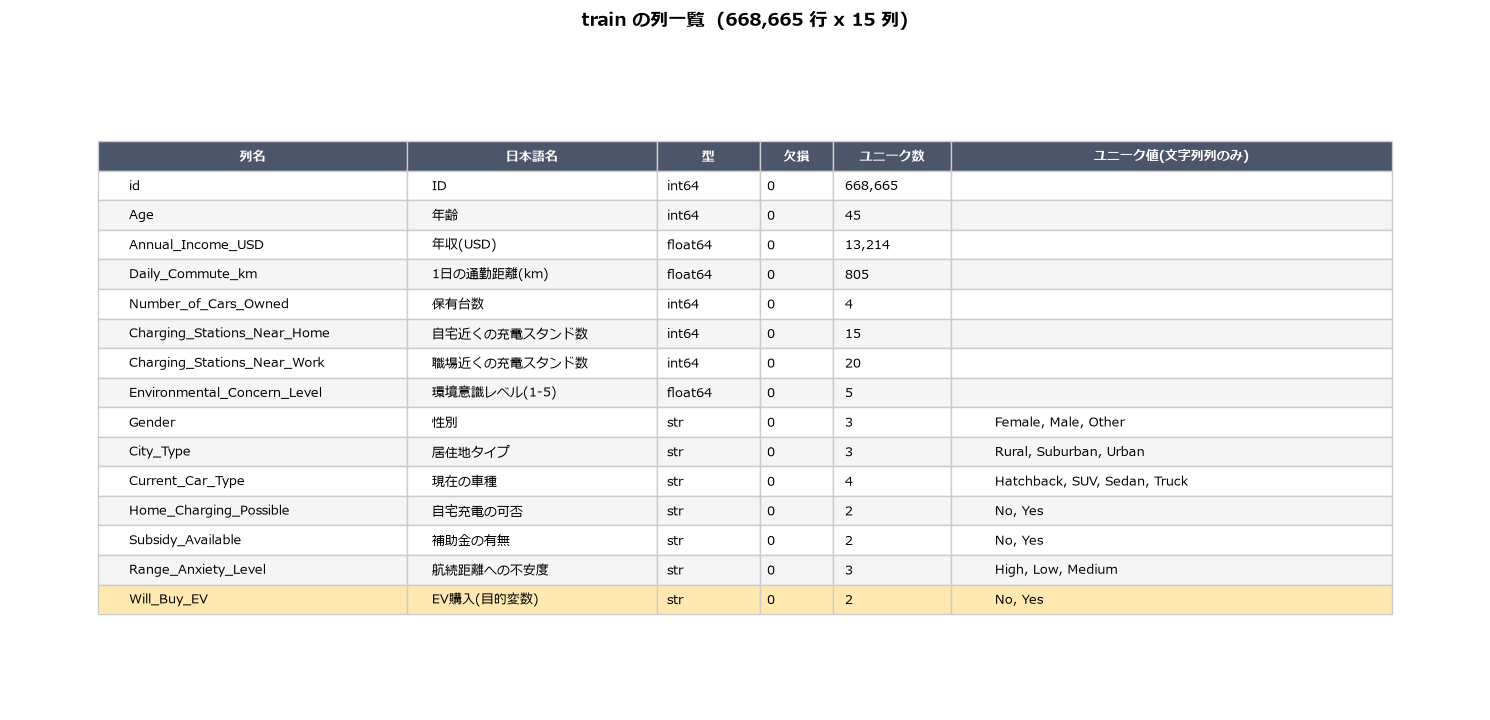

In [3]:
import matplotlib as mpl

# Windows 標準の日本語フォントを使う(無い場合は英字フォントのまま)
for _f in ["Meiryo", "Yu Gothic", "MS Gothic"]:
    if _f in {f.name for f in mpl.font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break

JP_NAMES = {
    "id": "ID",
    "Age": "年齢",
    "Annual_Income_USD": "年収(USD)",
    "Daily_Commute_km": "1日の通勤距離(km)",
    "Number_of_Cars_Owned": "保有台数",
    "Charging_Stations_Near_Home": "自宅近くの充電スタンド数",
    "Charging_Stations_Near_Work": "職場近くの充電スタンド数",
    "Environmental_Concern_Level": "環境意識レベル(1-5)",
    "Gender": "性別",
    "City_Type": "居住地タイプ",
    "Current_Car_Type": "現在の車種",
    "Home_Charging_Possible": "自宅充電の可否",
    "Subsidy_Available": "補助金の有無",
    "Range_Anxiety_Level": "航続距離への不安度",
    "Will_Buy_EV": "EV購入(目的変数)",
}

rows = []
for col in train.columns:
    is_str = train[col].dtype == object or pd.api.types.is_string_dtype(train[col])
    uniq = sorted(train[col].unique()) if is_str else []
    rows.append([
        col,
        JP_NAMES.get(col, ""),
        str(train[col].dtype),
        f"{train[col].isnull().sum():,}",
        f"{train[col].nunique():,}",
        ", ".join(map(str, uniq)) if is_str else "",
    ])

HEADERS = ["列名", "日本語名", "型", "欠損", "ユニーク数", "ユニーク値(文字列列のみ)"]
fig, ax = plt.subplots(figsize=(15, 0.42 * len(rows) + 1))
ax.axis("off")
tbl = ax.table(cellText=rows, colLabels=HEADERS, loc="center", cellLoc="left",
               colWidths=[0.21, 0.17, 0.07, 0.05, 0.08, 0.30])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#cccccc")
    if r == 0:                                   # ヘッダー
        cell.set_facecolor("#4c566a")
        cell.set_text_props(color="white", weight="bold")
    elif rows[r - 1][0] == "Will_Buy_EV":        # 目的変数を強調
        cell.set_facecolor("#ffe9b0")
    elif r % 2 == 0:
        cell.set_facecolor("#f5f5f5")

ax.set_title(f"train の列一覧  ({train.shape[0]:,} 行 x {train.shape[1]} 列)",
             fontsize=13, weight="bold", pad=14)
plt.tight_layout()
plt.show()

## 目的変数

Yes が 17.5% の不均衡データ。AUC で評価するため閾値調整は不要。

In [4]:
print(train[TARGET].value_counts())
print("購入率:", (train[TARGET] == "Yes").mean().round(4))

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64
購入率: 0.1746


## カーディナリティ

**このコンペで最も重要な情報。** 年収は 13,214 種類の値を持ち、木モデルは既定で 255 ビンに
まとめてしまうため、値ごとの違いが見えなくなる。後の Target Encoding / ビン数引き上げの根拠になる。

In [5]:
NUM_COLS = train.select_dtypes(include=[np.number]).columns.drop("id").tolist()
CAT_COLS = [c for c in train.columns if c not in NUM_COLS + ["id", TARGET]]
pd.DataFrame({
    "nunique": [train[c].nunique() for c in NUM_COLS + CAT_COLS],
    "dtype": [str(train[c].dtype) for c in NUM_COLS + CAT_COLS],
}, index=NUM_COLS + CAT_COLS)

,nunique,dtype
Age,45,int64
Annual_Income_USD,13214,float64
Daily_Commute_km,805,float64
Number_of_Cars_Owned,4,int64
Charging_Stations_Near_Home,15,int64
Charging_Stations_Near_Work,20,int64
Environmental_Concern_Level,5,float64
Gender,3,str
City_Type,3,str
Current_Car_Type,4,str


## 分布 — 数値列(Yes/No 積み上げ)

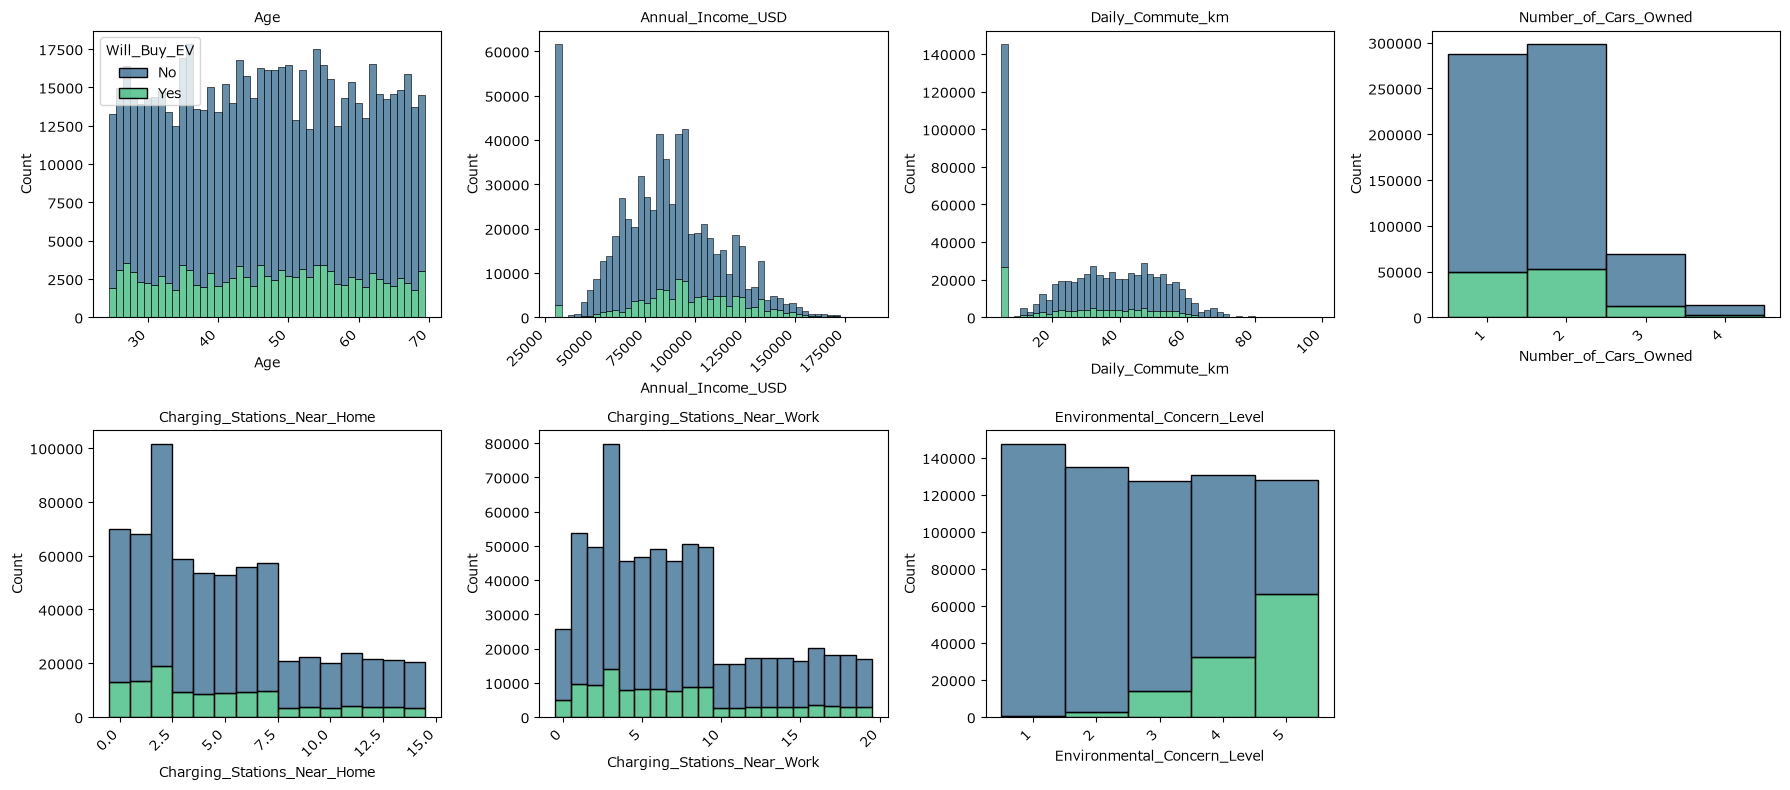

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), NUM_COLS):
    discrete = train[col].nunique() <= 50
    sns.histplot(data=train, x=col, hue=TARGET, multiple="stack", palette="viridis",
                 discrete=discrete, bins="auto" if discrete else 50, ax=ax, legend=(col == NUM_COLS[0]))
    ax.set_title(col, fontsize=10)
    # 年収など桁の大きい列は目盛りが重なるため斜めにする
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
axes.ravel()[-1].axis("off")
plt.tight_layout()

## 値ごとの購入率

厳密値 Target Encoding が効いた理由が見える図。年収は右肩上がり(約5% → 約39%)、
`Environmental_Concern_Level` はレベル1の約1%からレベル5の約52%まで動く。

また年収 30,000 と通勤距離 5.0km に値が集中しており、生成時に下限でクリップされたと思われる。

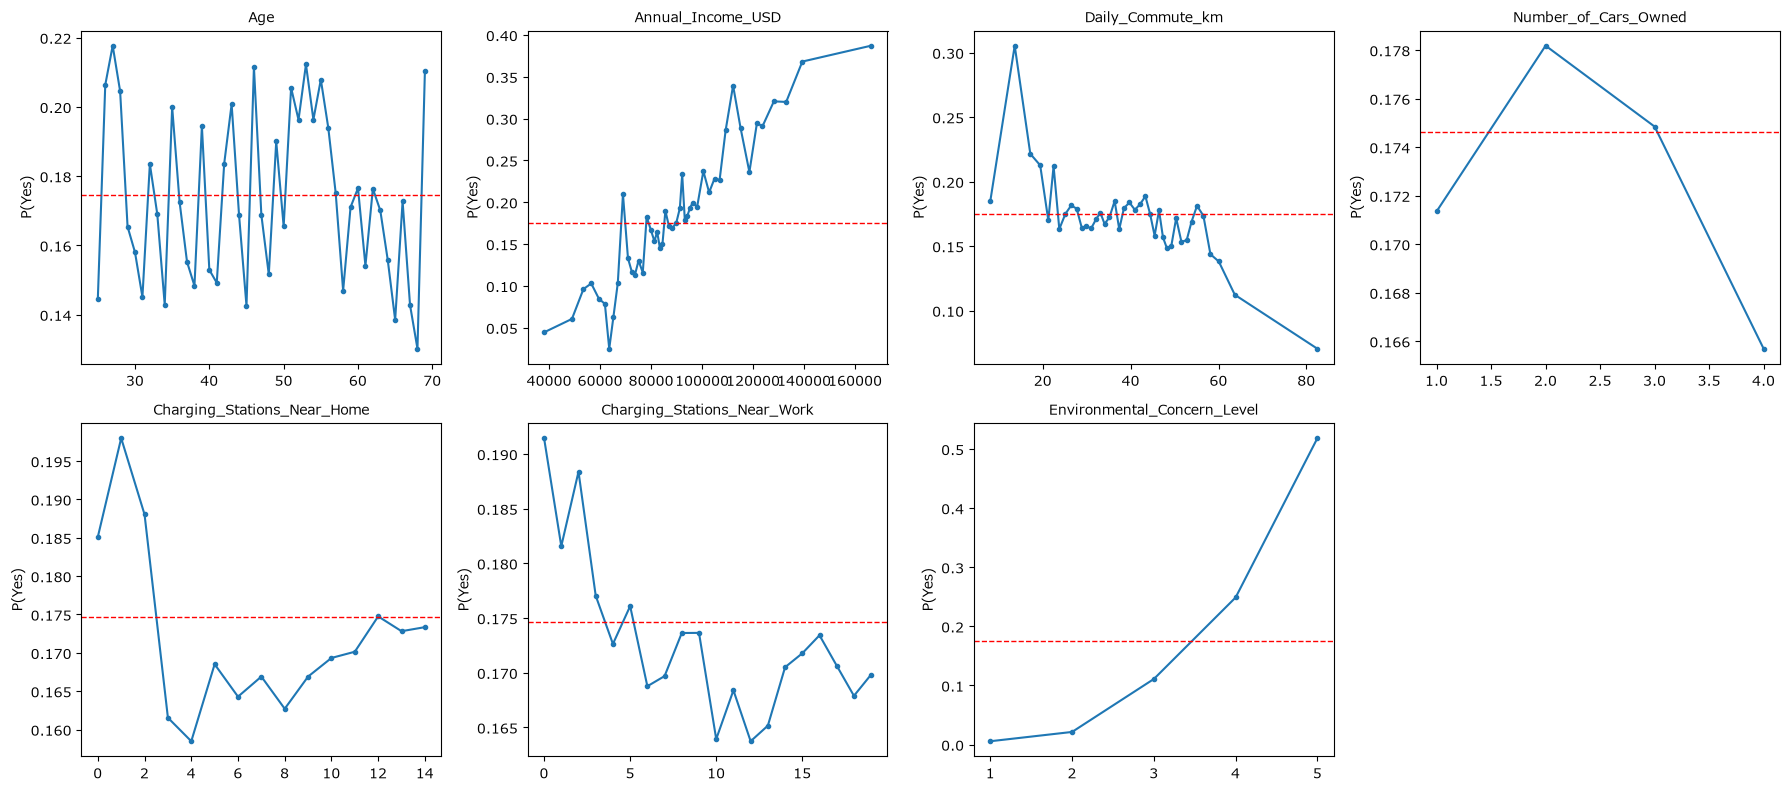

In [7]:
y = (train[TARGET] == "Yes").astype(int)
base = y.mean()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), NUM_COLS):
    key = train[col] if train[col].nunique() <= 50 else pd.qcut(train[col], 50, duplicates="drop").apply(lambda iv: iv.mid)
    rate = y.groupby(key).mean()
    ax.plot(rate.index.astype(float), rate.values, marker="o", ms=3)
    ax.axhline(base, color="red", ls="--", lw=1)
    ax.set_title(col, fontsize=10); ax.set_ylabel("P(Yes)")
axes.ravel()[-1].axis("off")
plt.tight_layout()

## 分布 — カテゴリ列と購入率

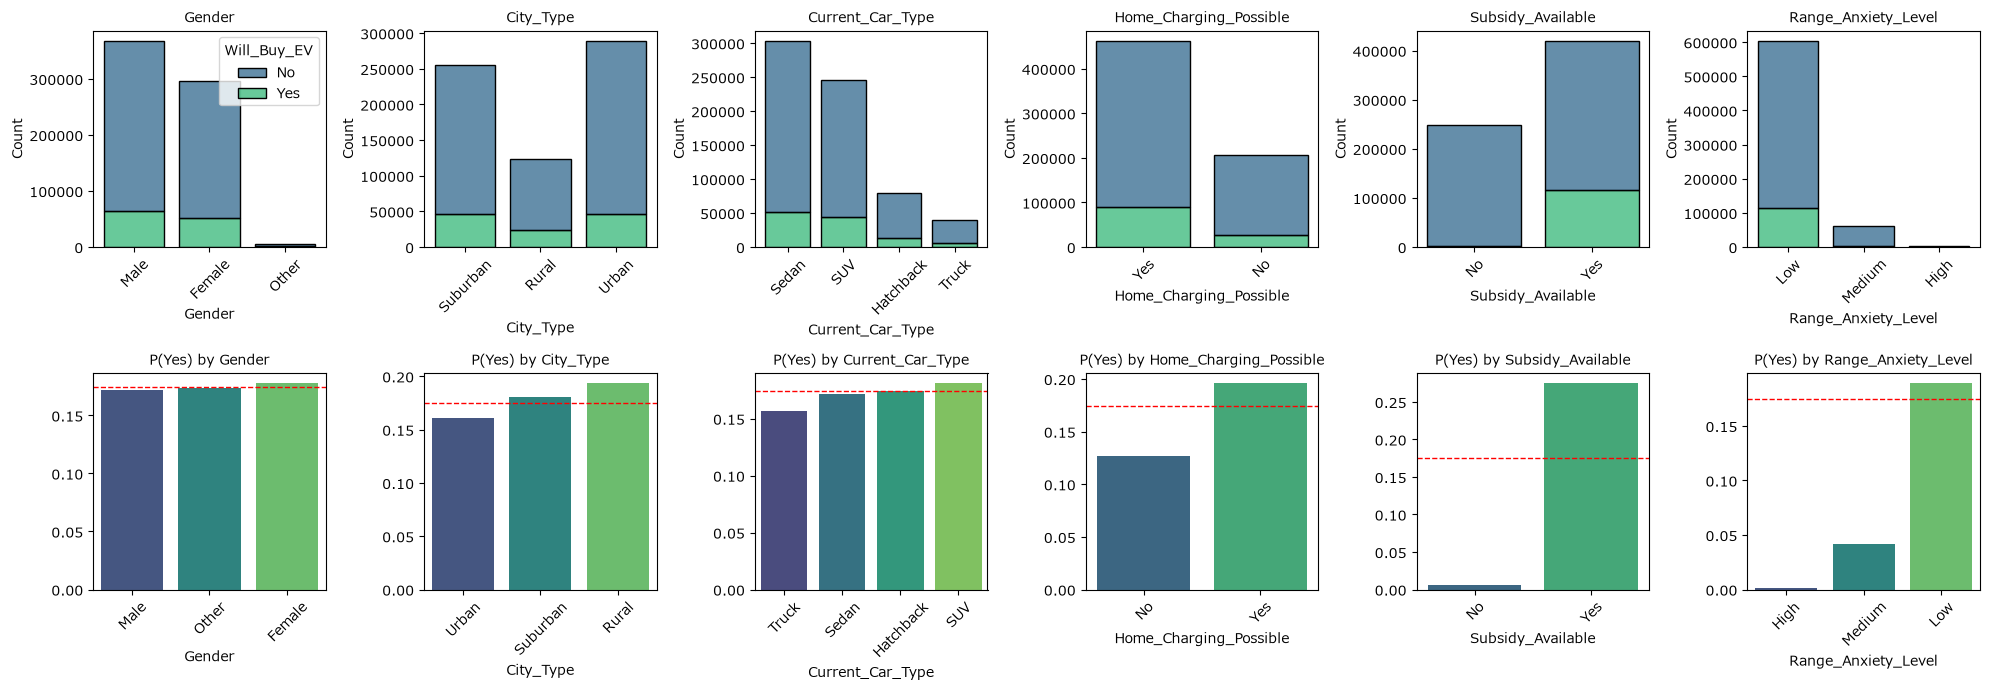

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, col in enumerate(CAT_COLS):
    sns.histplot(data=train, x=col, hue=TARGET, multiple="stack", palette="viridis",
                 shrink=0.8, ax=axes[0, i], legend=(i == 0))
    axes[0, i].set_title(col, fontsize=10); axes[0, i].tick_params(axis="x", rotation=45)
    rate = y.groupby(train[col]).mean().sort_values()
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index,
                palette="viridis", legend=False, ax=axes[1, i])
    axes[1, i].axhline(base, color="red", ls="--", lw=1)
    axes[1, i].set_title(f"P(Yes) by {col}", fontsize=10); axes[1, i].tick_params(axis="x", rotation=45)
plt.tight_layout()

## まとめ

- train 668,665 行 / test 286,571 行、**欠損なし**、購入率 17.5%
- `Environmental_Concern_Level` の効きが圧倒的、次いで年収と通勤距離
- **年収は 13,214 種類**あり、木の既定ビン数(255)では値ごとの違いが潰れる
  → 厳密値 Target Encoding とビン数引き上げにつながる
- 年収 30,000・通勤距離 5.0km に下限クリップと思われる集中がある